# Plugin Mimicry

This takes two audio samples - one unprocessed, and one processed, and learns to make the first into the second.

In [1]:
import torch
import torch.nn as nn
import math
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.io import wavfile
from sklearn.preprocessing import MinMaxScaler, Normalizer

In [1121]:
class WaveDataGenerator(Dataset):
    def __init__(self, input_file, target_file, block_size=512):
        super().__init__()
        self.block_size = block_size
        
        fs1, orig = wavfile.read(input_file)
        print(orig.shape)
        orig_chunked = orig.swapaxes(1, 0)[0].transpose().reshape(1, -1, 1)
        oc = [orig_chunked[:, i:i+512, :] for i in range(0, orig_chunked.shape[1], 512)]
        print(len(oc), oc[0].shape)
        self.oc = [x for x in oc if x.shape[1] == 512]
        fs2, orig2 = wavfile.read(target_file)
        orig2_chunked = orig2.swapaxes(1, 0)[0].transpose().reshape((1, -1, 1))
        oc2 = [orig2_chunked[:, i:i+512, :] for i in range(0, orig2_chunked.shape[1], 512)]
        self.oc2 = [x for x in oc2 if x.shape[1] == 512]
        assert fs1 == fs2
        print("length in 512 size blocks: ", len(oc))
        print(len(self.oc), len(self.oc2))
        self.input_max = max([x.max().item() for x in self.oc]) / 32768
        self.input_min = min([x.min().item() for x in self.oc]) / 32768
        
        self.target_max = max([x.max().item() for x in self.oc2]) / 32768
        self.target_min = min([x.min().item() for x in self.oc2]) / 32768
        
        self.input_mean = sum([x.max().item() for x in self.oc]) / 32768 / len(self.oc)
        self.target_mean = max([x.max().item() for x in self.oc2]) / 32768 / len(self.oc2)
        
        self.x = (np.array(self.oc) / 32768).astype(np.float32)
        self.target = (np.array(self.oc2) / 32768).astype(np.float32)
        self.x = self.x[:,0,:,0]
        self.target = self.target[:,0,:,0]
        
        print("input max/min: ", self.input_max, self.input_min)
        print("target max/min: ", self.target_max, self.target_min)
        print("means:", self.input_mean, self.target_mean)
        print(self.oc2[0].shape)
        self.num_blocks_delay = 0

        self.x = torch.tensor(self.x).cuda()
        self.target = torch.tensor(self.target).cuda()
        
    def __len__(self):
        return min(len(self.oc), len(self.oc2))

    def __getitem__(self, idx):
        x = self.x[idx].unsqueeze(-1)
        target = self.target[idx].unsqueeze(-1)
        return x, target

The guts of the neural network.

In [1326]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=50):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model, device='cuda')
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1), :]
        return self.dropout(x)

class Net (torch.nn.Module):
    def __init__(self, block_size=512, num_prev_states=50):
        super(Net, self).__init__()
        
        self.block_size = block_size
        self.num_prev_states = num_prev_states
        
        self.l0 = nn.Linear(self.block_size, self.block_size, bias=False).cuda()
        self.l1 = nn.Linear(self.block_size, self.block_size, bias=False).cuda()
        
        self.pe = PositionalEncoding(512, dropout=0., max_len=self.num_prev_states).cuda()
        
        self.q_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.k_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.v_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        
        self.attn = nn.MultiheadAttention(self.block_size, self.block_size, bias=True)
        self.attn_out = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.attn_project = nn.Linear(self.num_prev_states, 1, bias=True).cuda()
        
        self.norm1 = nn.LayerNorm((self.num_prev_states, self.block_size)).cuda()
        self.norm2 = nn.LayerNorm((self.block_size)).cuda()
        
        self.residual_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.final_layer = nn.Linear(self.block_size, self.block_size, bias=True).cuda()
        self.attention_pool = nn.Linear(self.block_size, 1, bias=True).cuda()
        
    def init_hidden(self, bs):
        
        self.past = torch.zeros((bs, self.num_prev_states, self.block_size), device='cuda')
    
    def forward(self, x):
        bs = x.size(0)
        
        x = torch.atan(self.l0(x.transpose(2,1)))
        x = nn.functional.elu(self.l1(x))
        
        orig_x = x.clone()
        
        self.past = torch.cat((self.past[:, 1:, :], x), dim=1)
        past = self.pe(self.past)
        past = self.norm1(past)
        
        q = torch.atan(self.q_layer(past))
        k = torch.atan(self.k_layer(past))
        v = torch.atan(self.v_layer(past))
        
        q = q.transpose(1, 0) # (SEQ_LEN, BS, EMBED_DIM)
        k = k.transpose(1, 0)
        v = v.transpose(1, 0)
        
        x, _ = self.attn(q, k, v)
        
        x = self.attn_out(x)
        x = x.permute(1, 2, 0)
        
        x = torch.atan(self.attn_project(x)).transpose(2, 1)
        
        x = torch.matmul(F.softmax(self.attention_pool(x), dim=1).transpose(-1, -2), x).squeeze(-2)
        
        x = x.unsqueeze(-1)
        
        x = x + torch.atan(self.residual_layer(orig_x)).transpose(2, 1)
        
        x = self.final_layer(x.transpose(2,1)).transpose(2,1)
        return x

## Pre-Training

In NLP we have language models that are "pre-trained" on a general task, then we "finetune" them for a specific task. I've extended that analogy to audio.

In the DataLoader(s) below remember to swap the `input_file` and `target_file`s with your own exported WAVs, and to adjust `num_prev_states` based on how long your effect's "reverb tail" is.

Batch size can usually be high for the pretraining step.

In [1327]:
bs = 32
dataloader = DataLoader(WaveDataGenerator(input_file='c:/Users/tomgr/Desktop/melange_2.wav', target_file='c:/Users/tomgr/Desktop/melange_2_target.wav'), batch_size=bs, shuffle=False, drop_last=True)
net = Net(num_prev_states=100) # If the effect you're mimicking has a short/long reverb tail or delay, adjust this
net.to('cuda')
optimizer = torch.optim.Adam(net.parameters(), lr=7e-5)
loss_fn = torch.nn.L1Loss()

(15710625, 2)
30685 (1, 512, 1)
length in 512 size blocks:  30685
30684 30684
input max/min:  0.999969482421875 -0.860260009765625
target max/min:  0.999969482421875 -1.0
means: 0.12683944393829796 3.258928048565621e-05
(1, 512, 1)


In [1328]:
# How many params in this network?
def getparams(x):
    params = 1
    for param in x.shape:
        params *= param
    return params
sum([getparams(x) for x in list(net.parameters())])

3254886

In [1329]:
for i in range(50):
    epoch_loss = 0.
    net.init_hidden(bs)
    for j, batch in enumerate(dataloader):
        inputs, targets = batch
        if inputs.shape[0] != bs:
            continue
        net.past = net.past.detach()
        output = net(inputs)
        loss = loss_fn(output, targets)
        epoch_loss += loss.item()
        loss.backward(retain_graph=False)
        optimizer.step()
        optimizer.zero_grad()
        net.zero_grad()
    print(f"Epoch {i} avg loss: {epoch_loss / j}")

Epoch 1 avg loss: 0.07818124223028017
Epoch 1 avg loss: 0.06594250725507794
Epoch 1 avg loss: 0.06422639933073905
Epoch 1 avg loss: 0.06345613612256927
Epoch 1 avg loss: 0.06262819639711457
Epoch 1 avg loss: 0.061853412259254524
Epoch 1 avg loss: 0.06118801150054577


KeyboardInterrupt: 

## Fine Tuning

Some concrete things that are different:
* Learning rate is less
* Batch size is reduced

In fact the batch size here is 1, because the network builds up its idea of "the past" one input block at a time, and I couldn't figure out how to adapt that to work with a larger batch size.

So you can think of the pre-training as learning to "make the present input sound like the present target output" and then this finetuning step as learning to "adjust output based on the past". Of course, this step is much slower.

In [1330]:
bs = 1
optimizer = torch.optim.Adam(net.parameters(), lr=7e-6)
loss_fn = torch.nn.L1Loss()
dataloader = DataLoader(WaveDataGenerator(input_file='c:/Users/tomgr/Desktop/melange_2.wav', target_file='c:/Users/tomgr/Desktop/melange_2_target.wav'), batch_size=bs, shuffle=False, drop_last=True)

(15710625, 2)
30685 (1, 512, 1)
length in 512 size blocks:  30685
30684 30684
input max/min:  0.999969482421875 -0.860260009765625
target max/min:  0.999969482421875 -1.0
means: 0.12683944393829796 3.258928048565621e-05
(1, 512, 1)


In [ ]:
for i in range(30):
    epoch_loss = 0.
    net.init_hidden(bs)
    for j, batch in enumerate(dataloader):
        inputs, targets = batch
        if inputs.shape[0] != bs:
            continue
        net.past = net.past.detach()
        output = net(inputs)
        loss = loss_fn(output, targets)
        epoch_loss += loss.item()
        loss.backward(retain_graph=False)
        optimizer.step()
        optimizer.zero_grad()
        net.zero_grad()
    print(f"Epoch {i} avg loss: {epoch_loss / j}")

Epoch 0 avg loss: 0.058290192814122635
Epoch 1 avg loss: 0.05757694225975226


In [1325]:
torch.save(net.state_dict(), "overdrive_reverb_net_1024_mono.bin")
# Now ready to use in Pyphonic!

## Get an idea of how it works

Plot one output based on one input. If you keep re-running the second cell below, you'll see how the output changes based on the past states.

In [1276]:
net.init_hidden(1)
idx = 0
x = torch.tensor(dataloader.dataset.x[idx]).view(-1, 1)
target = torch.tensor(dataloader.dataset.target[idx]).view(-1, 1)

<ipython-input-1276-a966ef72f1ba>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(dataloader.dataset.x[idx]).view(-1, 1)
<ipython-input-1276-a966ef72f1ba>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(dataloader.dataset.target[idx]).view(-1, 1)


-0.9134892 tensor(7.3200, device='cuda:0')


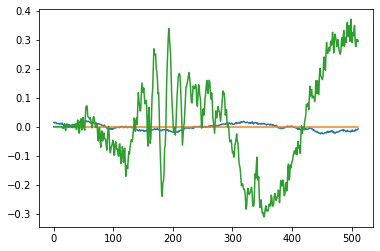

In [1322]:
net.eval()
x= torch.zeros_like(x) # Zero the current input here to check how it responds to past states (history) only
yhat = net(x.unsqueeze(0).cuda())
out = yhat[0].detach().cpu().numpy()
plt.plot(out)
plt.plot(x.detach().cpu().numpy())
plt.plot(target.detach().cpu().numpy())
net.train();
print(out.sum(), target.sum())